# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# Import necessary libraries
# - data handling
import pandas as pd
import numpy as np

from warnings import filterwarnings
filterwarnings('ignore')

# - plotting
import matplotlib.pyplot as plt
import seaborn as sns

# - text preprocessing
import nltk
import re
import string
from collections import Counter

# - NLP libraries
from nltk.tokenize import word_tokenize,sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer, SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams

# -  NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

# - sklearn libraries
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# - deep learning libraries
import torch
from transformers import AutoModelForCausalLM,AutoTokenizer
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


###REAL WASTE DATASET

In [2]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
#loading of the datasets




In [3]:
#image characteristics


### 1.2 Explore Text Datasets

##WASTE DESCRIPTION DATASET

In [4]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
df_description = pd.read_csv('waste_descriptions.csv')
df_description

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
...,...,...,...,...,...
4995,new red tea bags,Food Organics,Keep separate from recyclable materials.,NaN,Biodegradable matter derived from plant or ani...
4996,torn white disposable diaper sealed,Miscellaneous Trash,Hazardous items like batteries require special...,NaN,Various non-recyclable materials often with mi...
4997,broken mini apple core,Food Organics,Place in organic waste or compost bin.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
4998,pink glass pitcher with food residue,Glass,"Place in glass recycling bin, sorted by color ...","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."


####Analyzing Vocabulary and Structure for Waste Description Dataset


In [5]:
#Checking shape of the dataset
print(df_description.shape)

(5000, 5)


In [6]:
#Checking the column names
print(df_description.columns)

Index(['description', 'category', 'disposal_instruction', 'common_confusion',
       'material_composition'],
      dtype='object')


In [7]:
#Knowing the overall info about the dataset
print(df_description.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB
None


In [8]:
#Checking for missing values
print(df_description.isnull().sum())

description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


###Understanding the distribution of categories for Waste Description Dataset

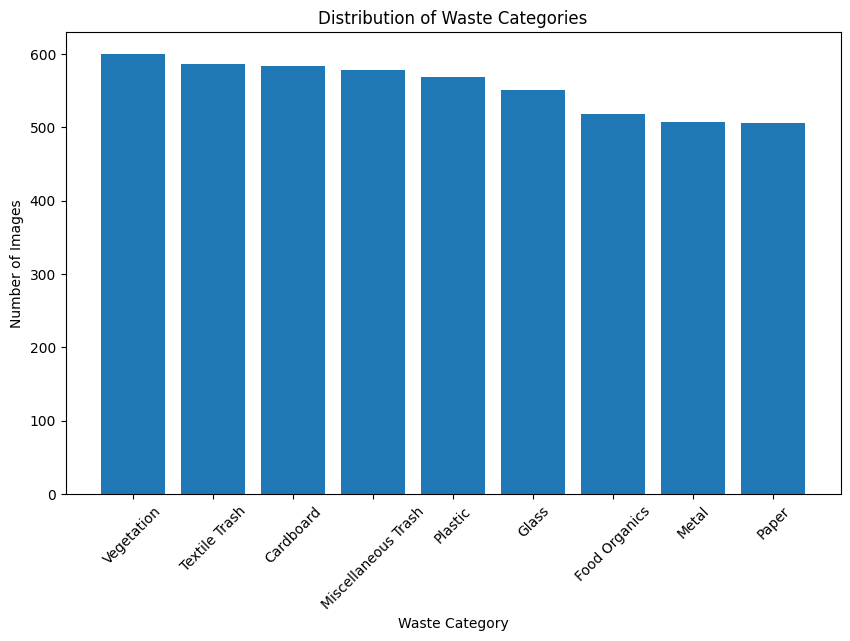

In [9]:
# understand the distribution of  categories
category_counts = df_description['category'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index,category_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Waste Categories')
plt.show()

#WASTE POLICY DOCUMENTS DATASET

In [10]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
df_policy_documents =  pd.read_json('waste_policy_documents.json')
df_policy_documents

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...,Metro City
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,METAL RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,PAPER RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,MISCELLANEOUS TRASH GUIDELINES\n\nItems That C...,Metro City
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,MUNICIPAL WASTE GUIDELINES\n\nGENERAL REQUIREM...,Metro City


In [11]:
#Checking the shape of the dataset
print(df_policy_documents.shape)

(14, 6)


In [12]:
#Understanding document organization an language

print(df_policy_documents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes
None


In [13]:
#checking the column names
print(df_policy_documents.columns)

Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='object')


In [14]:
#Checking the datatypes for each column
print(df_policy_documents.dtypes)

policy_id              int64
policy_type           object
categories_covered    object
effective_date        object
document_text         object
jurisdiction          object
dtype: object


In [15]:
#Checking if there are duplicates
# df_policy_documents.duplicated().sum()

### 1.3 Create Data Pipelines

In [16]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path


# Calculate the total number of classes automatically from the directory structure


# List all class folders


# Count all images


# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set


# Configure dataset for performance


In [17]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

In [18]:
# Install package (first run only)
# !pip install -q sentence-transformers

# import pandas as pd
# import numpy as np
# import re
# import string

# from sklearn.model_selection import train_test_split
# from sentence_transformers import SentenceTransformer
# TEXT CLEANING FUNCTION
# ==========================================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

    # COMBINE USEFUL TEXT FIELDS
# ==========================================================

df_description["combined_text"] = (
    df_description["description"].fillna("") + " " +
    df_description["disposal_instruction"].fillna("") + " " +
    df_description["common_confusion"].fillna("") + " " +
    df_description["material_composition"].fillna("")
)

df_policy_documents["combined_text"] = (
    df_policy_documents["policy_type"].fillna("") + " " +
    df_policy_documents["categories_covered"].fillna("").astype(str) + " " +
    df_policy_documents["document_text"].fillna("") + " " +
    df_policy_documents["jurisdiction"].fillna("")
)


In [19]:
# CLEAN TEXT
df_description["clean_text"] = (
    df_description["combined_text"]
    .apply(clean_text)
)

df_policy_documents["clean_text"] = (
    df_policy_documents["combined_text"]
    .apply(clean_text)
)

In [20]:
# TRAIN TEST SPLIT
train_desc, test_desc = train_test_split(
    df_description,
    test_size=0.20,
    random_state=42,
    stratify=df_description["category"]
)

print(f"Training descriptions: {len(train_desc)}")
print(f"Testing descriptions : {len(test_desc)}")

Training descriptions: 4000
Testing descriptions : 1000


In [21]:
# ==========================================================
# LOAD SENTENCE TRANSFORMER MODEL
# ==========================================================

model = SentenceTransformer('all-MiniLM-L6-v2')

# ==========================================================
# CREATE EMBEDDINGS
# ==========================================================

description_embeddings = model.encode(
    df_description["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

policy_embeddings = model.encode(
    df_policy_documents["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

# ==========================================================
# EMBEDDING DATAFRAMES
# ==========================================================

description_embedding_df = pd.DataFrame(description_embeddings)

description_embedding_df.insert(
    0,
    "category",
    df_description["category"]
)

policy_embedding_df = pd.DataFrame(policy_embeddings)

policy_embedding_df.insert(
    0,
    "policy_id",
    df_policy_documents["policy_id"]
)

# ==========================================================
# SAVE EMBEDDINGS
# ==========================================================

description_embedding_df.to_csv(
    "waste_description_embeddings.csv",
    index=False
)

policy_embedding_df.to_csv(
    "policy_document_embeddings.csv",
    index=False
)

# ==========================================================
# DISPLAY SUMMARY
# ==========================================================

print("\nDescription Embeddings Shape:")
print(description_embeddings.shape)

print("\nPolicy Embeddings Shape:")
print(policy_embeddings.shape)

print("\nEmbedding Dimensions:")
print(description_embeddings.shape[1])

print("\nDescription Categories:")
print(df_description["category"].value_counts())

print("\nSample Waste Record:")
print(df_description[["description","category"]].head(1))

print("\nSample Policy Record:")
print(df_policy_documents[["policy_id","policy_type"]].head(1))

print("\nFiles Saved:")
print("- waste_description_embeddings.csv")
print("- policy_document_embeddings.csv")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Description Embeddings Shape:
(5000, 384)

Policy Embeddings Shape:
(14, 384)

Embedding Dimensions:
384

Description Categories:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64

Sample Waste Record:
                description       category
0  soiled silver tablecloth  Textile Trash

Sample Policy Record:
   policy_id                         policy_type
0          1  Textile Trash Recycling Guidelines

Files Saved:
- waste_description_embeddings.csv
- policy_document_embeddings.csv


In [22]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

In [66]:
# Prepare documents for RAG

# Make a copy of the policy documents
rag_documents = df_policy_documents.copy()

# Convert each row into one text document
rag_documents["document_text"] = rag_documents.astype(str).agg(" ".join, axis=1)

# Remove duplicate documents based only on the text
rag_documents = rag_documents.drop_duplicates(
    subset=["document_text"]
).reset_index(drop=True)

# Create the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings for the documents
document_embeddings = embedding_model.encode(
    rag_documents["document_text"].tolist(),
    convert_to_numpy=True
)

# Check the results
print("Number of documents:", len(rag_documents))
print("Embedding shape:", document_embeddings.shape)

# Display the prepared documents
rag_documents[["document_text"]].head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Number of documents: 14
Embedding shape: (14, 384)


,document_text
0,1 Textile Trash Recycling Guidelines ['Textile...
1,2 Glass Recycling Guidelines ['Glass'] 2023-01...
2,3 Food Organics Recycling Guidelines ['Food Or...
3,4 Plastic Recycling Guidelines ['Plastic'] 202...
4,5 Vegetation Recycling Guidelines ['Vegetation...


In [67]:
# RAG document preprocessing
rag_data = df_description.copy()

# Replace missing confusion information
rag_data["common_confusion"] = rag_data["common_confusion"].fillna(
    "No specific common confusion provided."
)

# Create a document containing useful waste-management information
rag_data["rag_document"] = (
    "Waste category: " + rag_data["category"] +
    ". Material composition: " + rag_data["material_composition"] +
    ". Disposal instruction: " + rag_data["disposal_instruction"] +
    ". Common confusion: " + rag_data["common_confusion"]
)

# Display examples
rag_data[
    ["category", "rag_document"]
].head()

,category,rag_document
0,Textile Trash,Waste category: Textile Trash. Material compos...
1,Glass,Waste category: Glass. Material composition: S...
2,Food Organics,Waste category: Food Organics. Material compos...
3,Textile Trash,Waste category: Textile Trash. Material compos...
4,Food Organics,Waste category: Food Organics. Material compos...


In [24]:
# Remove exact duplicate documents
rag_documents = rag_data["rag_document"].drop_duplicates().reset_index(drop=True)

print("Number of unique RAG documents:", len(rag_documents))

Number of unique RAG documents: 90


Create embeddings for RAGto allow the system to later compare a resident's question or waste category with the stored waste-management information.

In [25]:
# Create embeddings for RAGto allow the system to later compare a resident's question or waste category with the stored waste-management information.

from sentence_transformers import SentenceTransformer
# Load a sentence-transformer model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for the RAG documents
rag_embeddings = embedding_model.encode(
    rag_documents.tolist(),
    show_progress_bar=True
)

print("Number of documents:", len(rag_documents))
print("Embedding shape:", rag_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Number of documents: 90
Embedding shape: (90, 384)


In [26]:
# level RAG knowledge base to give compact RAG knowledge base containing one document for each waste category.
category_documents = []

for category, group in df_description.groupby("category"):

    # Get unique instructions
    instructions = group["disposal_instruction"].dropna().unique()

    # Get material composition
    composition = group["material_composition"].dropna().unique()

    # Get common confusion information
    confusions = group["common_confusion"].dropna().unique()

    document = (
        f"Waste Category: {category}\n"
        f"Material Composition: {composition[0]}\n"
        f"Disposal Instructions: {' '.join(instructions)}\n"
        f"Common Confusion: {' '.join(confusions)}"
    )

    category_documents.append({
        "category": category,
        "document": document
    })

rag_category_df = pd.DataFrame(category_documents)

rag_category_df

,category,document
0,Cardboard,Waste Category: Cardboard\nMaterial Compositio...
1,Food Organics,Waste Category: Food Organics\nMaterial Compos...
2,Glass,Waste Category: Glass\nMaterial Composition: S...
3,Metal,Waste Category: Metal\nMaterial Composition: A...
4,Miscellaneous Trash,Waste Category: Miscellaneous Trash\nMaterial ...
5,Paper,Waste Category: Paper\nMaterial Composition: C...
6,Plastic,Waste Category: Plastic\nMaterial Composition:...
7,Textile Trash,Waste Category: Textile Trash\nMaterial Compos...
8,Vegetation,Waste Category: Vegetation\nMaterial Compositi...


In [27]:
# Create embeddings for the category-level knowledge base

rag_category_embeddings = embedding_model.encode(
    rag_category_df["document"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", rag_category_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (9, 384)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [28]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [29]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [30]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [31]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [32]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [33]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [34]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [35]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [36]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [37]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [38]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

In [39]:
# Prepare documents for retrieval
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

# Load the waste descriptions dataset
df_description = pd.read_csv("waste_descriptions.csv")

# Check the available columns
print("Columns:")
print(df_description.columns.tolist())

print("\nDataset shape:", df_description.shape)

Columns:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

Dataset shape: (5000, 5)


In [40]:
# create the documents:
# Fill missing values in text fields
df_description["disposal_instruction"] = (
    df_description["disposal_instruction"]
    .fillna("")
)

df_description["material_composition"] = (
    df_description["material_composition"]
    .fillna("")
)

df_description["common_confusion"] = (
    df_description["common_confusion"]
    .fillna("")
)

# Create a document for each waste item
df_description["rag_document"] = (
    "Waste category: " + df_description["category"].astype(str) +
    ". Material composition: " + df_description["material_composition"].astype(str) +
    ". Disposal instruction: " + df_description["disposal_instruction"].astype(str) +
    ". Common confusion: " + df_description["common_confusion"].astype(str)
)

# Remove duplicate documents
rag_documents = (
    df_description["rag_document"]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Number of unique retrieval documents:", len(rag_documents))

# Display a few examples
for i in range(min(3, len(rag_documents))):
    print(f"\nDocument {i + 1}:")
    print(rag_documents.iloc[i])

Number of unique retrieval documents: 90

Document 1:
Waste category: Textile Trash. Material composition: Fabric made from natural or synthetic fibers, may include blends.. Disposal instruction: Look for textile recycling programs in your area.. Common confusion: 

Document 2:
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Remove caps, lids, and corks before recycling.. Common confusion: 

Document 3:
Waste category: Food Organics. Material composition: Biodegradable matter derived from plant or animal sources.. Disposal instruction: If no compost available, place in general waste.. Common confusion: 


In [41]:
# Create embeddings
# Load a pre-trained sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert the documents into numerical embeddings
document_embeddings = embedding_model.encode(
    rag_documents.tolist(),
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding shape: (90, 384)


In [42]:
# Create a retrieval dataframe- it will be used when implementing the actual RAG retrieval mechanism:
# Store documents and their embeddings together
rag_knowledge_base = pd.DataFrame({
    "document": rag_documents,
})

rag_knowledge_base["embedding"] = list(document_embeddings)

print("RAG knowledge base:")
print(rag_knowledge_base.head())

RAG knowledge base:
                                            document  \
0  Waste category: Textile Trash. Material compos...   
1  Waste category: Glass. Material composition: S...   
2  Waste category: Food Organics. Material compos...   
3  Waste category: Food Organics. Material compos...   
4  Waste category: Plastic. Material composition:...   

                                           embedding  
0  [-0.028363954, -0.0021506173, 0.010085642, -0....  
1  [0.04745693, -0.013603807, 0.028714938, -0.011...  
2  [0.07238554, -0.011421662, 0.014496125, -0.000...  
3  [0.02660487, -0.03396433, 0.022627233, -0.0098...  
4  [-0.0021686477, 0.0004760409, 0.018298628, -0....  


### 4.2 Implement RAG-based System

In [43]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

In [44]:
# Implement RAG-import the required libraries:
# TODO: Select a pre-trained language model and implement RAG

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import util
import torch

In [45]:
# Load the pre-trained language model
# Select a lightweight pre-trained language model
model_name = "google/flan-t5-small"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load language model
generator_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Language model loaded successfully.")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Language model loaded successfully.


In [46]:
# Create the retrieval function -takes a resident's waste question and finds the most relevant documents from the knowledge base we created in the previous cell.
def retrieve_documents(query, top_k=3):
    """
    Retrieve the most relevant waste-management documents
    for a given user query.
    """

    # Convert the query into an embedding
    query_embedding = embedding_model.encode(
        query,
        convert_to_tensor=True
    )

    # Convert stored embeddings to a tensor
    document_tensor = torch.tensor(
        np.array(document_embeddings)
    )

    # Calculate cosine similarity
    similarities = util.cos_sim(
        query_embedding,
        document_tensor
    )[0]

    # Get the top matching documents
    top_results = torch.topk(
        similarities,
        k=min(top_k, len(rag_documents))
    )

    retrieved = []

    for score, index in zip(
        top_results.values,
        top_results.indices
    ):
        retrieved.append({
            "document": rag_documents[int(index)],
            "score": float(score)
        })

    return retrieved



In [47]:
# Create the RAG generation function
def generate_recycling_instruction(query, top_k=3):
    """
    Retrieve relevant waste-management information
    and generate a recycling instruction.
    """

    # Retrieve relevant documents
    retrieved_docs = retrieve_documents(
        query,
        top_k=top_k
    )

    # Combine retrieved documents
    context = "\n\n".join(
        [item["document"] for item in retrieved_docs]
    )

    # Create the prompt
    prompt = f"""
You are EcoSort, a waste-management assistant.

Use only the information provided in the context
to answer the resident's question.

Give clear and practical recycling or disposal
instructions.

Context:
{context}

Resident question:
{query}

Answer:
"""

    # Tokenize the prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Generate response
    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.7
    )

    # Decode the generated answer
    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer, retrieved_docs

In [48]:
# Test the RAG system
questions = [
    "How should I dispose of a glass bottle?",
    "What should I do with plastic waste?",
    "How should I dispose of food waste?"
]

for question in questions:
    answer, retrieved_docs = generate_recycling_instruction(question)

    print("=" * 70)
    print("Question:", question)
    print("\nGenerated instruction:")
    print(answer)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Question: How should I dispose of a glass bottle?

Generated instruction:
Disposal instruction: Remove caps, lids, and corks before recycling.
Question: What should I do with plastic waste?

Generated instruction:
Dispose of waste
Question: How should I dispose of food waste?

Generated instruction:
Disposal instruction: Keep separate from recyclable materials.


In [49]:
# Inspect RAG
question = "How should I dispose of a glass bottle?"

answer, retrieved_docs = generate_recycling_instruction(
    question,
    top_k=3
)

print("QUESTION:")
print(question)

print("\nRETRIEVED DOCUMENTS:")

for i, item in enumerate(retrieved_docs, start=1):
    print(f"\nDocument {i}")
    print("Similarity:", round(item["score"], 4))
    print(item["document"])

print("\nGENERATED ANSWER:")
print(answer)

QUESTION:
How should I dispose of a glass bottle?

RETRIEVED DOCUMENTS:

Document 1
Similarity: 0.4815
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Remove caps, lids, and corks before recycling.. Common confusion: Window glass, drinking glasses, and ceramics should not go in container glass recycling.

Document 2
Similarity: 0.4754
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Broken glass should be wrapped and labeled before disposal.. Common confusion: Window glass, drinking glasses, and ceramics should not go in container glass recycling.

Document 3
Similarity: 0.4596
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Non-container glass may require special disposal.. Common confusion: Window glass, drinking glasses, and

### 4.3 Adjust and Evaluate the System

In [50]:
 #TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [51]:
#TODO: Train the RAG-based system
# Create sample questions to test the RAG system
test_questions = [
    "How should I dispose of a glass bottle?",
    "What should I do with plastic waste?",
    "How should I dispose of food waste?",
    "Can cardboard be recycled?",
    "How should I dispose of metal waste?",
    "What should I do with old clothes?"
]

print("Number of test questions:", len(test_questions))

Number of test questions: 6


In [52]:
#  Run the RAG system
results = []

for question in test_questions:
    answer, retrieved_docs = generate_recycling_instruction(
        question,
        top_k=3
    )

    results.append({
        "question": question,
        "answer": answer,
        "retrieved_documents": retrieved_docs
    })

print("RAG system testing completed.")

RAG system testing completed.


In [53]:
# Display the generated instructions
for result in results:
    print("=" * 80)
    print("QUESTION:")
    print(result["question"])

    print("\nGENERATED INSTRUCTION:")
    print(result["answer"])

    print("\nTOP RETRIEVED DOCUMENTS:")

    for i, doc in enumerate(result["retrieved_documents"], start=1):
        print(f"\nDocument {i} - Similarity: {doc['score']:.4f}")
        print(doc["document"][:500])

QUESTION:
How should I dispose of a glass bottle?

GENERATED INSTRUCTION:
Disposal instruction: Remove caps, lids, and corks before recycling.

TOP RETRIEVED DOCUMENTS:

Document 1 - Similarity: 0.4815
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Remove caps, lids, and corks before recycling.. Common confusion: Window glass, drinking glasses, and ceramics should not go in container glass recycling.

Document 2 - Similarity: 0.4754
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Broken glass should be wrapped and labeled before disposal.. Common confusion: Window glass, drinking glasses, and ceramics should not go in container glass recycling.

Document 3 - Similarity: 0.4596
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: N

In [54]:
# Check retrieval quality-To check whether the system is retrieving relevant waste-management information.
# Calculate the average similarity score for each question

for result in results:
    scores = [
        doc["score"]
        for doc in result["retrieved_documents"]
    ]

    average_score = np.mean(scores)

    print("=" * 60)
    print("Question:", result["question"])
    print("Average retrieval similarity:", round(average_score, 4))

Question: How should I dispose of a glass bottle?
Average retrieval similarity: 0.4722
Question: What should I do with plastic waste?
Average retrieval similarity: 0.6309
Question: How should I dispose of food waste?
Average retrieval similarity: 0.5592
Question: Can cardboard be recycled?
Average retrieval similarity: 0.6975
Question: How should I dispose of metal waste?
Average retrieval similarity: 0.681
Question: What should I do with old clothes?
Average retrieval similarity: 0.4127


In [55]:
# TODO: Adjust sampling methods/parameters
def generate_recycling_instruction(
    query,
    top_k=3,
    max_new_tokens=100,
    temperature=0.7,
    do_sample=True,
    top_p=0.9
):
    # Retrieve relevant documents
    retrieved_docs = retrieve_documents(
        query,
        top_k=top_k
    )

    # Combine retrieved documents into context
    context = "\n\n".join(
        [item["document"] for item in retrieved_docs]
    )

    # Create prompt
    prompt = f"""
You are EcoSort, a waste-management assistant.

Use only the information provided in the context
to answer the resident's question.

Give clear, practical recycling or disposal instructions.

Context:
{context}

Resident question:
{query}

Answer:
"""

    # Tokenize prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Generate response using sampling parameters
    outputs = generator_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=top_p
    )

    # Convert tokens back to text
    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer, retrieved_docs

In [56]:
# Test the sampling parameters
question = "How should I dispose of a glass bottle?"

answer, retrieved_docs = generate_recycling_instruction(
    question,
    top_k=3,
    max_new_tokens=100,
    temperature=0.7,
    do_sample=True,
    top_p=0.9
)

print("Question:")
print(question)

print("\nGenerated answer:")
print(answer)

Question:
How should I dispose of a glass bottle?

Generated answer:
Disposal Instruction: Remove glass caps, lids, and corks before recycling.


In [57]:
# compare different sampling approaches:
settings = [
    {
        "name": "Low temperature",
        "temperature": 0.3,
        "top_p": 0.9
    },
    {
        "name": "Balanced",
        "temperature": 0.7,
        "top_p": 0.9
    },
    {
        "name": "More varied",
        "temperature": 1.0,
        "top_p": 0.95
    }
]

question = "What should I do with plastic waste?"

for setting in settings:
    answer, _ = generate_recycling_instruction(
        question,
        top_k=3,
        max_new_tokens=100,
        temperature=setting["temperature"],
        do_sample=True,
        top_p=setting["top_p"]
    )

    print("=" * 70)
    print(setting["name"])
    print("Temperature:", setting["temperature"])
    print("Top-p:", setting["top_p"])
    print("\nAnswer:")
    print(answer)

Low temperature
Temperature: 0.3
Top-p: 0.9

Answer:
Dispose of waste.
Balanced
Temperature: 0.7
Top-p: 0.9

Answer:
Dispose of the waste.
More varied
Temperature: 1.0
Top-p: 0.95

Answer:
Dispose of plastic waste


In [58]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

In [59]:
# TODO: Evaluate the quality of generated instructions

evaluation_results = []

for question in test_questions:
    answer, retrieved_docs = generate_recycling_instruction(
        question,
        top_k=3,
        max_new_tokens=100,
        temperature=0.7,
        do_sample=True,
        top_p=0.9
    )

    similarity_scores = [
        doc["score"] for doc in retrieved_docs
    ]

    average_similarity = np.mean(similarity_scores)

    evaluation_results.append({
        "question": question,
        "answer": answer,
        "average_similarity": average_similarity,
        "top_similarity": max(similarity_scores)
    })

print("Evaluation completed.")

Evaluation completed.


In [60]:
# Display the evaluation results
for result in evaluation_results:
    print("=" * 80)
    print("Question:")
    print(result["question"])

    print("\nGenerated instruction:")
    print(result["answer"])

    print("\nAverage retrieval similarity:",
          round(result["average_similarity"], 4))

    print("Top retrieval similarity:",
          round(result["top_similarity"], 4))

Question:
How should I dispose of a glass bottle?

Generated instruction:
Disposal instruction: Remove caps, lids, and corks before recycling.

Average retrieval similarity: 0.4722
Top retrieval similarity: 0.4815
Question:
What should I do with plastic waste?

Generated instruction:
Remove labelling

Average retrieval similarity: 0.6309
Top retrieval similarity: 0.6343
Question:
How should I dispose of food waste?

Generated instruction:
Disposal Instruction: Use a clean, sanded paper towel to clean up waste.

Average retrieval similarity: 0.5592
Top retrieval similarity: 0.5627
Question:
Can cardboard be recycled?

Generated instruction:
No

Average retrieval similarity: 0.6975
Top retrieval similarity: 0.7135
Question:
How should I dispose of metal waste?

Generated instruction:
Waste category: Metal. Material composition: Aluminum, steel, tin or mixed metal alloys.

Average retrieval similarity: 0.681
Top retrieval similarity: 0.6884
Question:
What should I do with old clothes?

Ge

In [61]:
# Check whether answers are useful
instruction_keywords = [
    "recycle",
    "recycling",
    "dispose",
    "disposal",
    "bin",
    "separate",
    "reuse",
    "waste"
]

for result in evaluation_results:

    answer_lower = result["answer"].lower()

    keyword_matches = sum(
        1 for word in instruction_keywords
        if word in answer_lower
    )

    result["instruction_keyword_count"] = keyword_matches
print("Keyword evaluation completed.")

Keyword evaluation completed.


In [62]:
# Create an evaluation table
evaluation_df = pd.DataFrame(evaluation_results)

evaluation_summary = evaluation_df[
    [
        "question",
        "average_similarity",
        "top_similarity",
        "instruction_keyword_count"
    ]
]

print(evaluation_summary)

                                  question  average_similarity  \
0  How should I dispose of a glass bottle?            0.472150   
1     What should I do with plastic waste?            0.630939   
2      How should I dispose of food waste?            0.559205   
3               Can cardboard be recycled?            0.697484   
4     How should I dispose of metal waste?            0.681030   
5       What should I do with old clothes?            0.412668   

   top_similarity  instruction_keyword_count  
0        0.481470                          2  
1        0.634265                          0  
2        0.562706                          2  
3        0.713544                          0  
4        0.688380                          1  
5        0.425109                          0  


In [63]:
# Overall retrieval quality
mean_similarity = evaluation_df["average_similarity"].mean()

print("Overall average retrieval similarity:",
      round(mean_similarity, 4))

print(
    "\nHigher similarity indicates that the retrieved "
    "documents are more semantically related to the question."
)

Overall average retrieval similarity: 0.5756

Higher similarity indicates that the retrieved documents are more semantically related to the question.


### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

The RAG-based system was evaluated using sample resident questions covering
different waste categories. Retrieval similarity scores were used to determine
how relevant the retrieved documents were to each question.

The generated instructions were also checked for practical recycling and
disposal information. The evaluation helps determine whether the system is
retrieving relevant information and generating useful responses based on the
retrieved context.

The results can be improved by adjusting the number of retrieved documents
(`top_k`), generation temperature, `top_p`, and maximum number of generated
tokens.

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions
def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """

    # Create a question from the waste category
    query = f"How should I dispose of {waste_category} waste?"

    # Use the RAG system to retrieve relevant documents
    answer, retrieved_docs = generate_recycling_instruction(
        query,
        top_k=3,
        max_new_tokens=100,
        temperature=0.7,
        do_sample=True,
        top_p=0.9
    )

    return answer, retrieved_docs

    # Test the function
    # Test the instruction generation function

instruction, documents = generate_recycling_instructions("Glass")

print("RECYCLING INSTRUCTIONS:")
print(instruction)

print("\nRELEVANT POLICY DOCUMENTS:")

for i, doc in enumerate(documents, start=1):
    print(f"\nDocument {i}")
    print("Similarity:", round(doc["score"], 4))
    print(doc["document"])

In [ ]:
categories = [
    "Glass",
    "Plastic",
    "Paper",
    "Cardboard",
    "Metal",
    "Food Organics",
    "Textile Trash",
    "Vegetation"
]

for category in categories:
    instruction, _ = generate_recycling_instructions(category)

    print("=" * 70)
    print("CATEGORY:", category)
    print("INSTRUCTIONS:")
    print(instruction)

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.